In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from iminuit import Minuit
import seaborn as sns
import matplotlib.patches as patches
from scipy import stats

In [2]:




def setup_plotting(ticksize=14, fontsize=16, figsize=(16, 9), dpi=150):
    """
    Global plotting setup:
    - Seaborn grey background
    - Custom reversed/de-saturated deep palette
    - Serif + STIX math fonts
    - Grid, linewidths, ticks, figure defaults
    """

    # --- Base style (grey background preserved) ---
    plt.style.use("seaborn-v0_8")
    sns.set()
    sns.set_context("paper", font_scale=1.4)
    sns.set_style("ticks")

    # --- Color palette ---
    colors = sns.color_palette("deep", 10, desat=0.8)
    #colors = sns.color_palette("husl", 10)
    #colors = sns.color_palette("tab10", 10)
    #colors = sns.color_palette("Set1", 10)
    #colors = colors[::-1]
    #colors.pop(2)
    sns.set_palette(colors)

    # --- Fonts ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"] + plt.rcParams["font.serif"],
        "mathtext.fontset": "stix",
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    return colors


def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)


In [3]:
colors = setup_plotting(ticksize=14, fontsize=16, figsize=(16, 9), dpi=150)

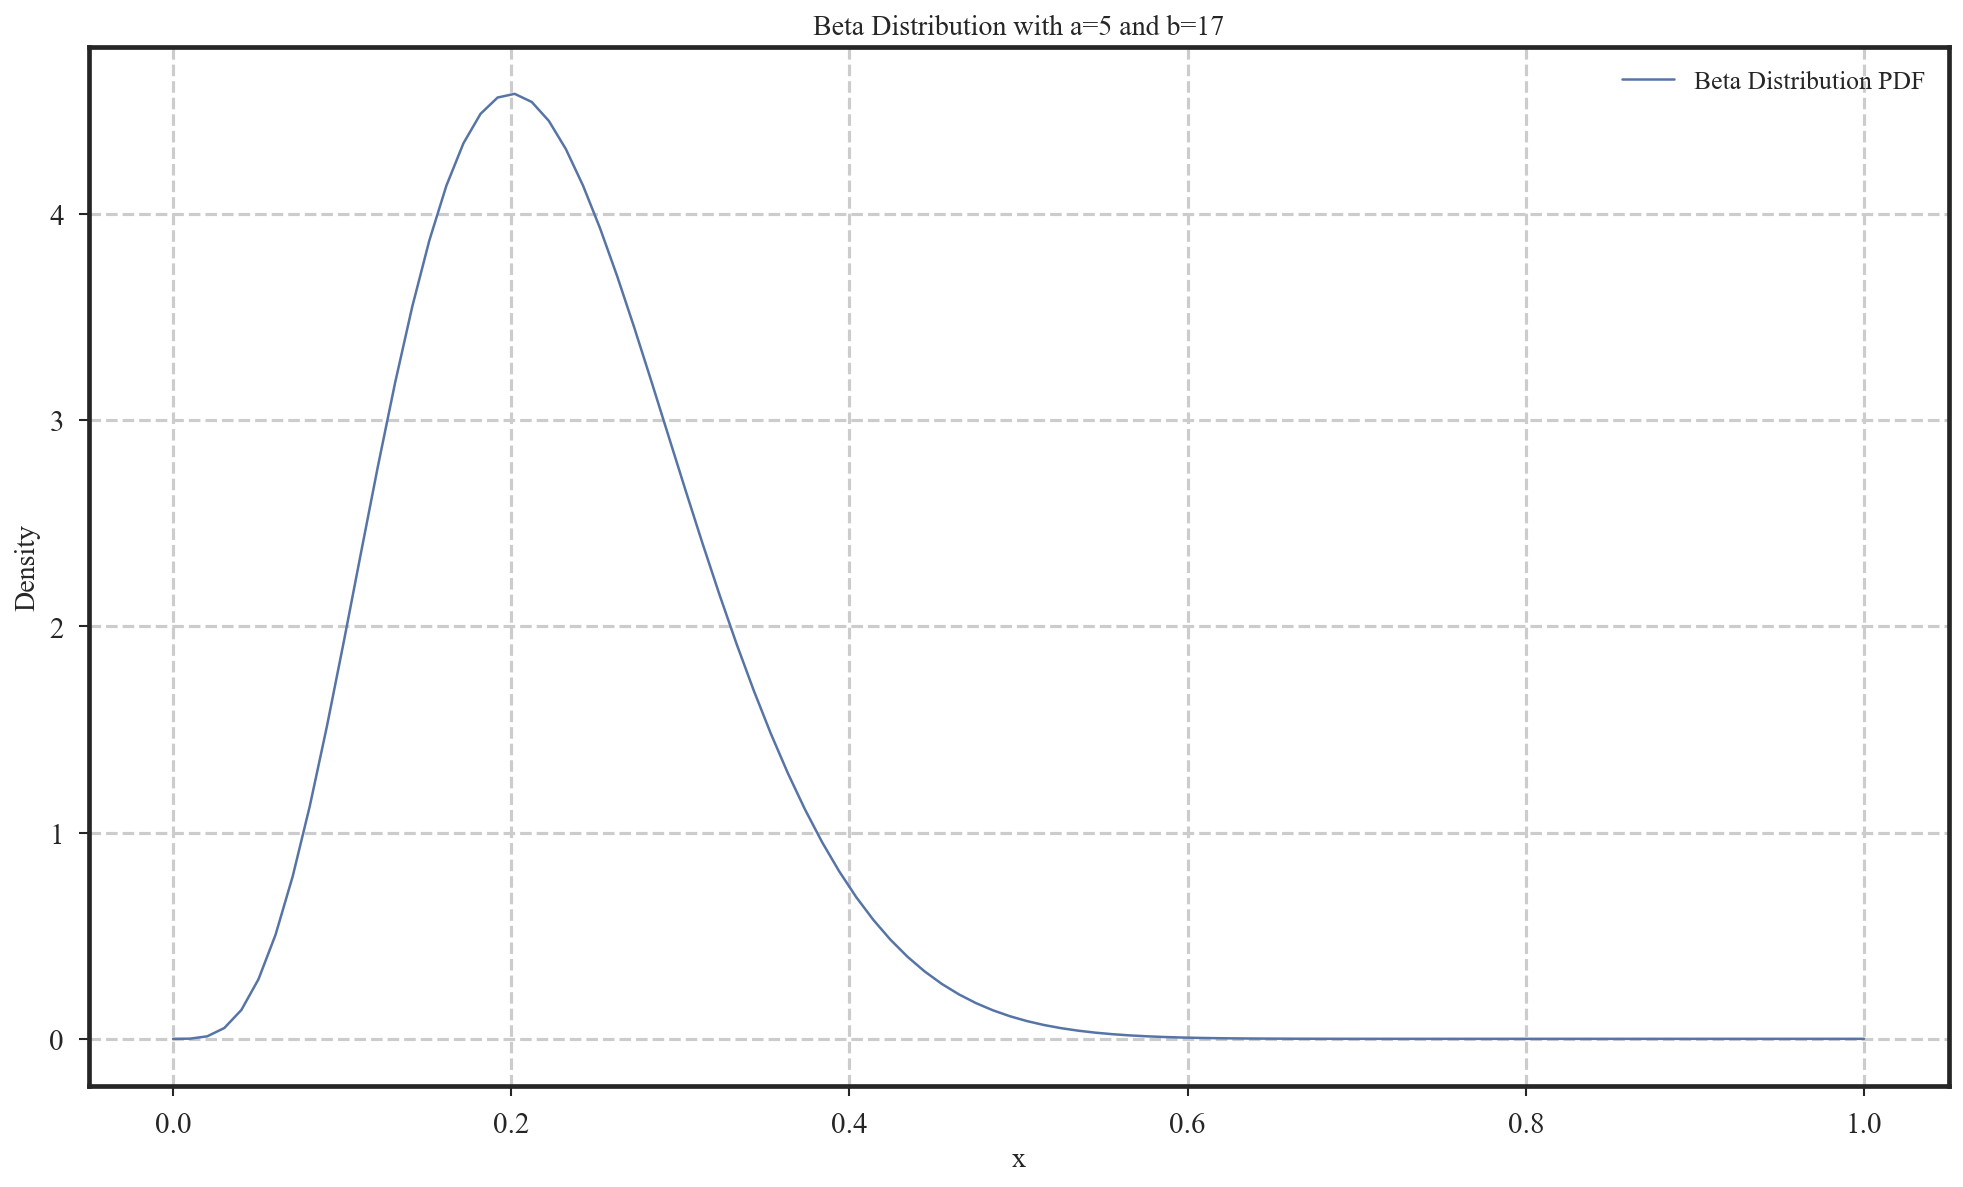

In [4]:
prior = stats.beta(a=5, b=17)
x_axis = np.linspace(0, 1, 100)
plt.plot(x_axis, prior.pdf(x_axis), label='Beta Distribution PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Beta Distribution with a=5 and b=17')
plt.legend()
plt.show()


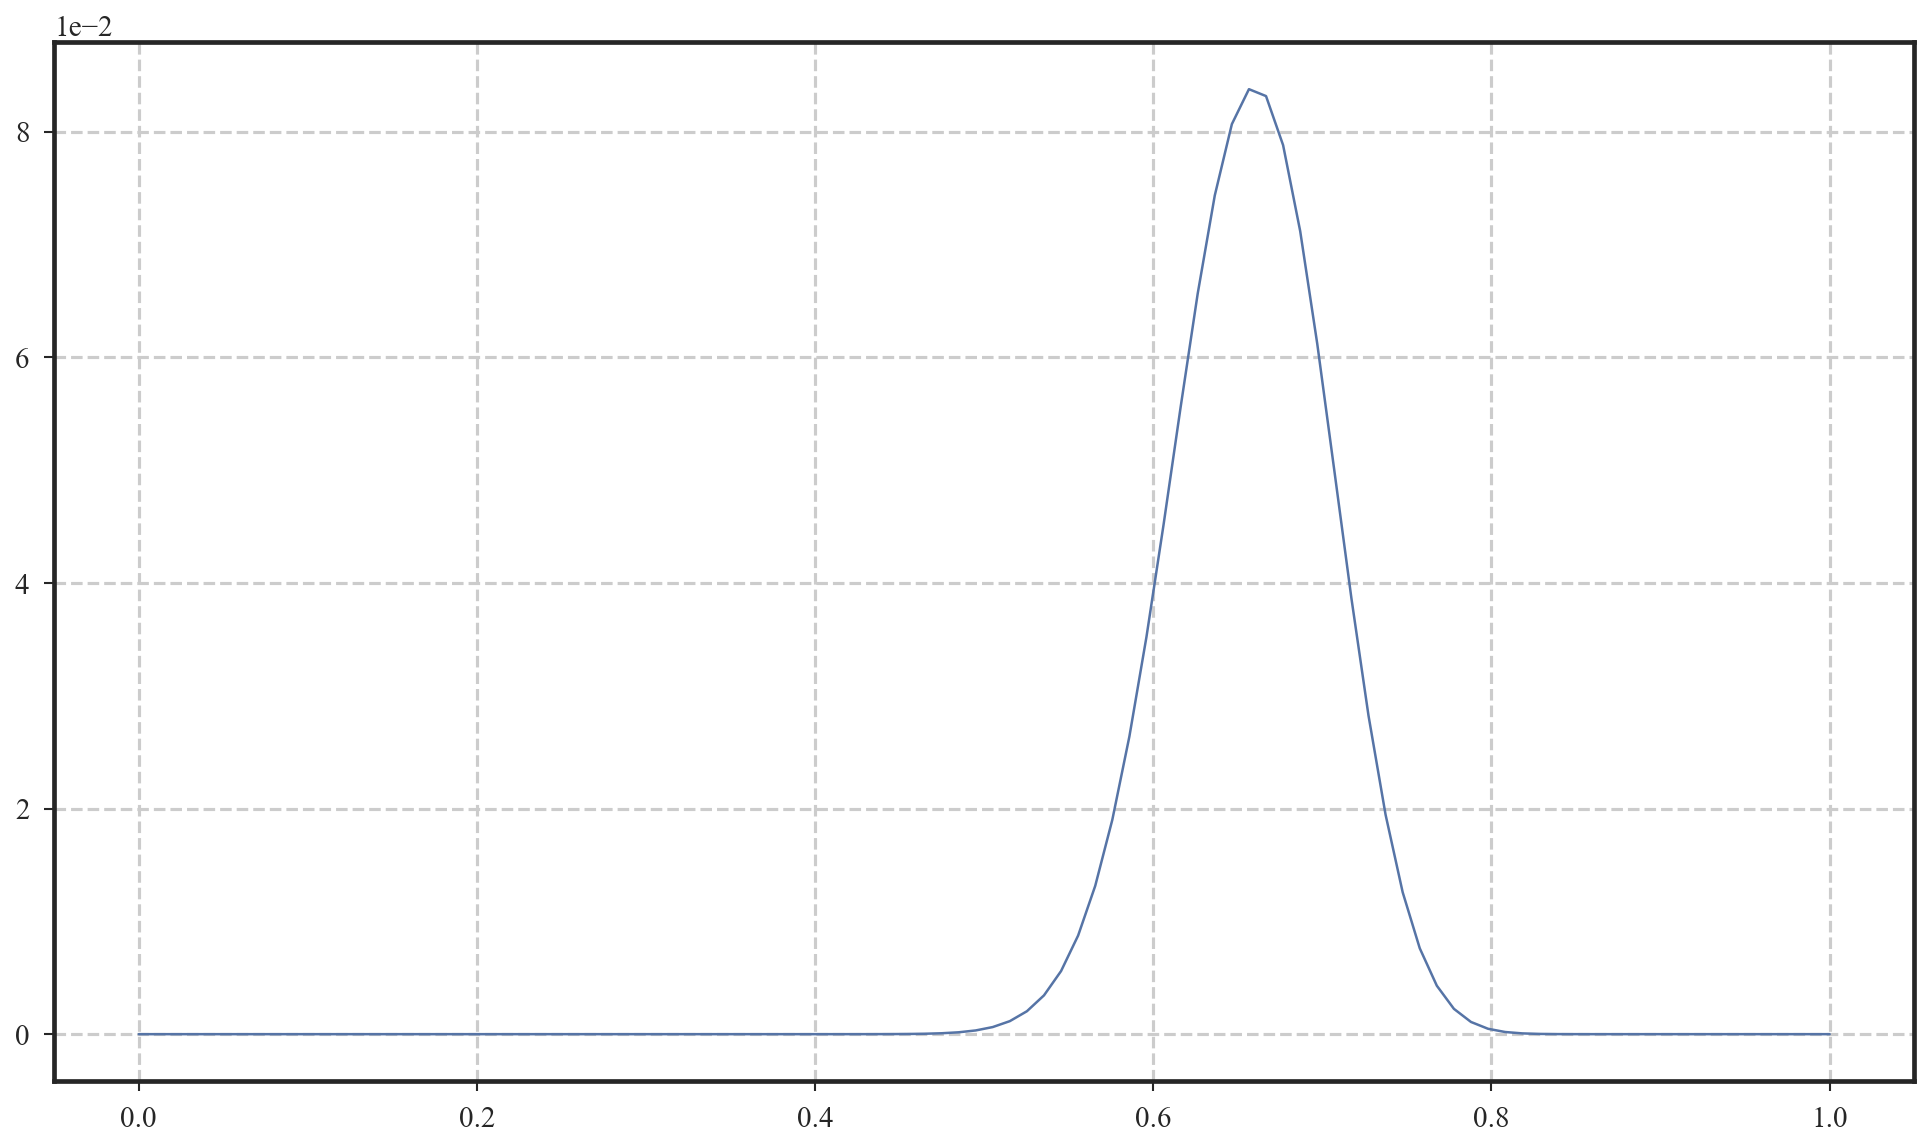

In [5]:
likelihood = stats.binom.pmf(k=66, n=100, p=x_axis)
plt.plot(x_axis, likelihood, label='Binomial Likelihood PMF')

In [6]:
# Check if likelihood is normalized
likelihood_integral = np.trapezoid(likelihood, x_axis)
print(f"Integral of likelihood over x: {likelihood_integral}")


Integral of likelihood over x: 0.009900990099009906


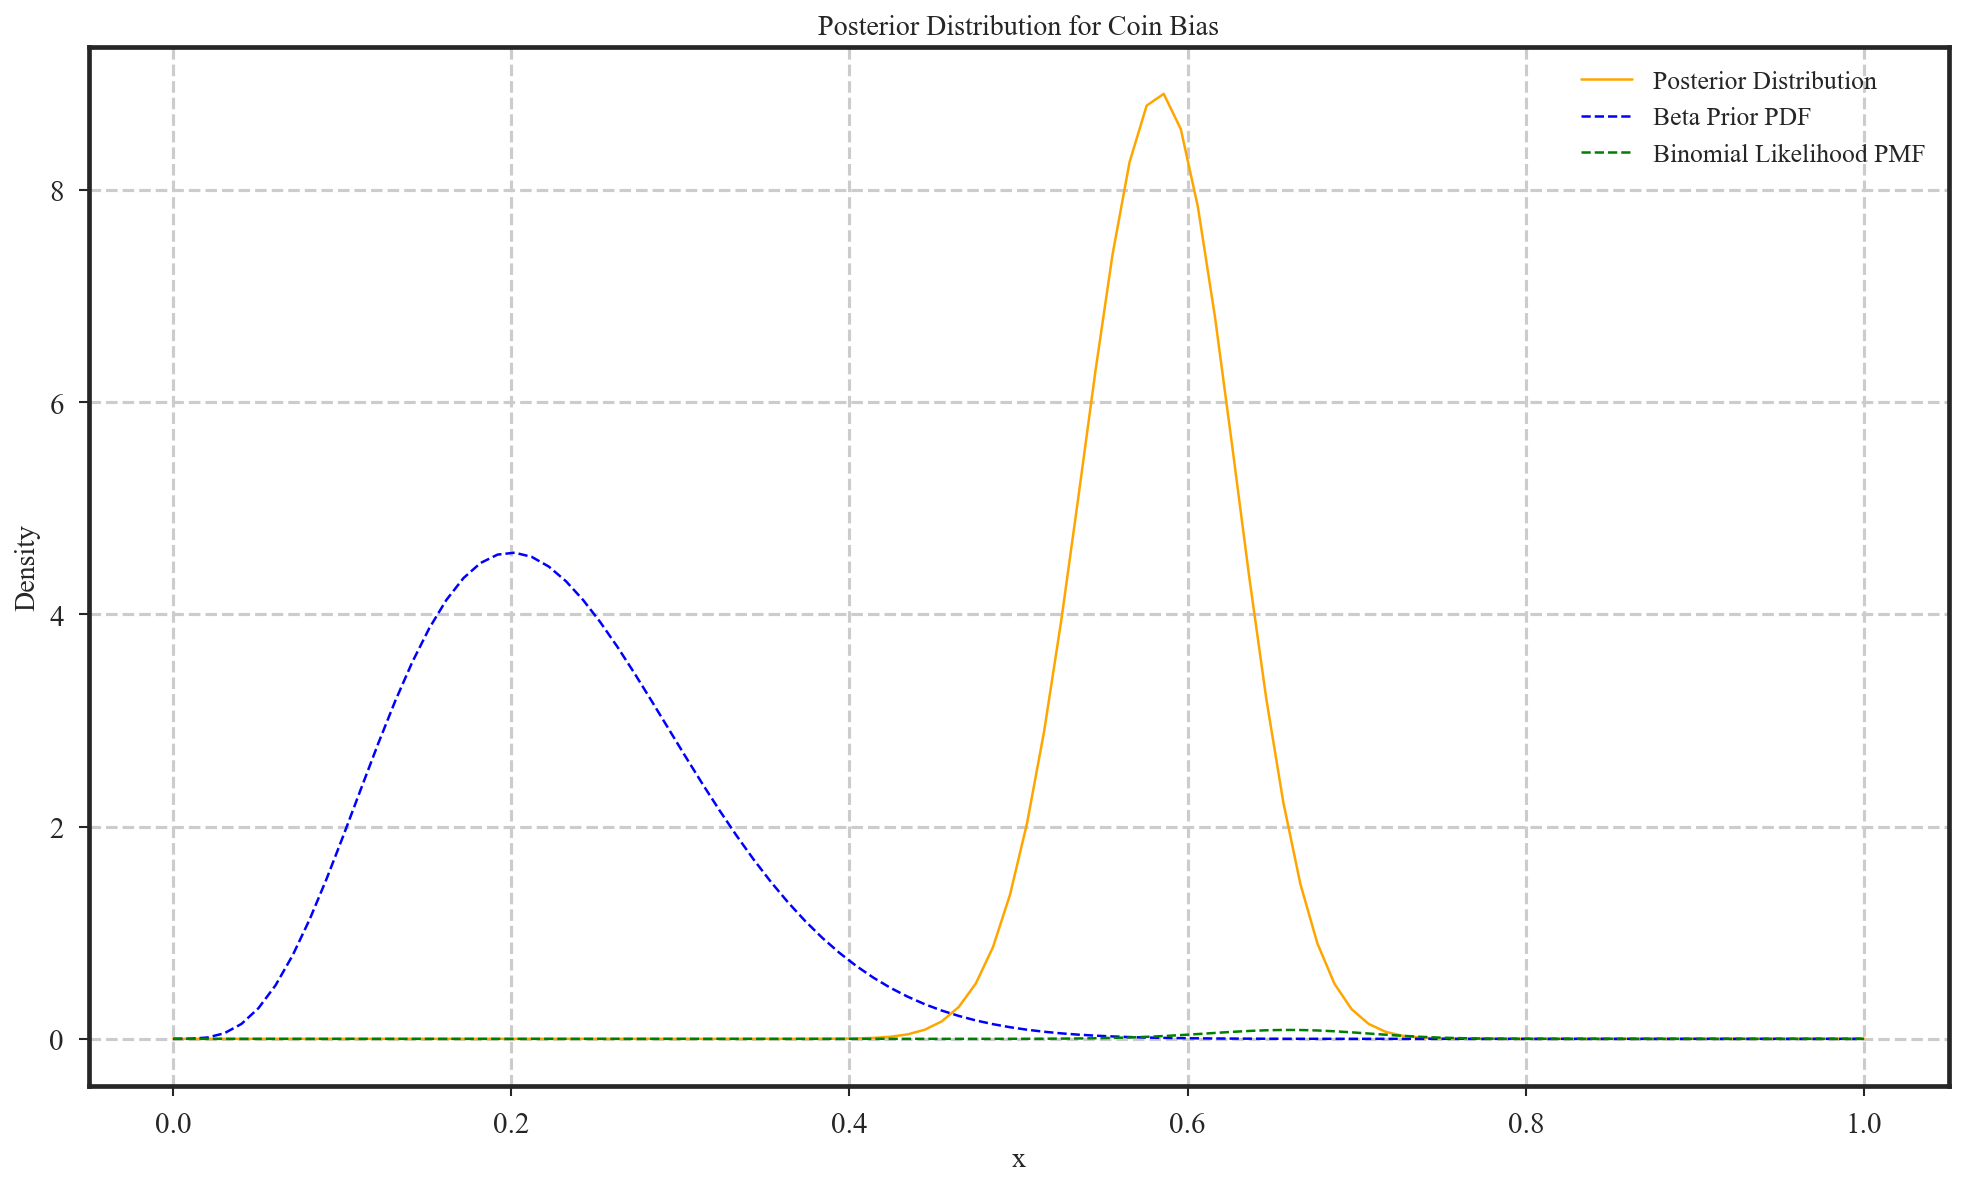

In [7]:
posterior = prior.pdf(x_axis) * likelihood
posterior /= np.trapezoid(posterior, x_axis)
plt.plot(x_axis, posterior, label='Posterior Distribution', color='orange')
plt.plot(x_axis, prior.pdf(x_axis), label='Beta Prior PDF', color='blue', linestyle='--')
plt.plot(x_axis, likelihood, label='Binomial Likelihood PMF', color='green', linestyle='--')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Posterior Distribution for Coin Bias')
plt.legend()
plt.show()